In [3]:
import xarray as xr 
from anemoi.datasets import open_dataset
import numpy as np
import yaml
import os 
import csv
import cfgrib
from pathlib import Path
import pathlib
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import zarr

In [2]:
era5   = open_dataset("EGU26/Anemoidatasets/era5_A2.zarr")
cerra  = open_dataset("EGU26/Anemoidatasets/Cerra_A.zarr")
erajan = open_dataset("EGU26/Anemoidatasets/era5_jan24_A.zarr")

In [13]:
time_idx      = 0
variable_name = "ws100"

var_idx_era5  = list(era5.variables).index(variable_name)
var_idx_cerra = list(cerra.variables).index(variable_name)

field_era5  = era5[time_idx][var_idx_era5, 0, :]
field_cerra = cerra[time_idx][var_idx_cerra, 0, :]

lons_era5  = era5.longitudes
lats_era5  = era5.latitudes
lons_cerra = cerra.longitudes
lats_cerra = cerra.latitudes
timestamp  = str(era5.dates[time_idx])

lon_min, lon_max = lons_cerra.min(), lons_cerra.max()
lat_min, lat_max = lats_cerra.min(), lats_cerra.max()

outside = ~(
    (lons_era5 >= lon_min) & (lons_era5 <= lon_max) &
    (lats_era5 >= lat_min) & (lats_era5 <= lat_max)
)

box_lons = [lon_min, lon_max, lon_max, lon_min, lon_min]
box_lats = [lat_min, lat_min, lat_max, lat_max, lat_min]

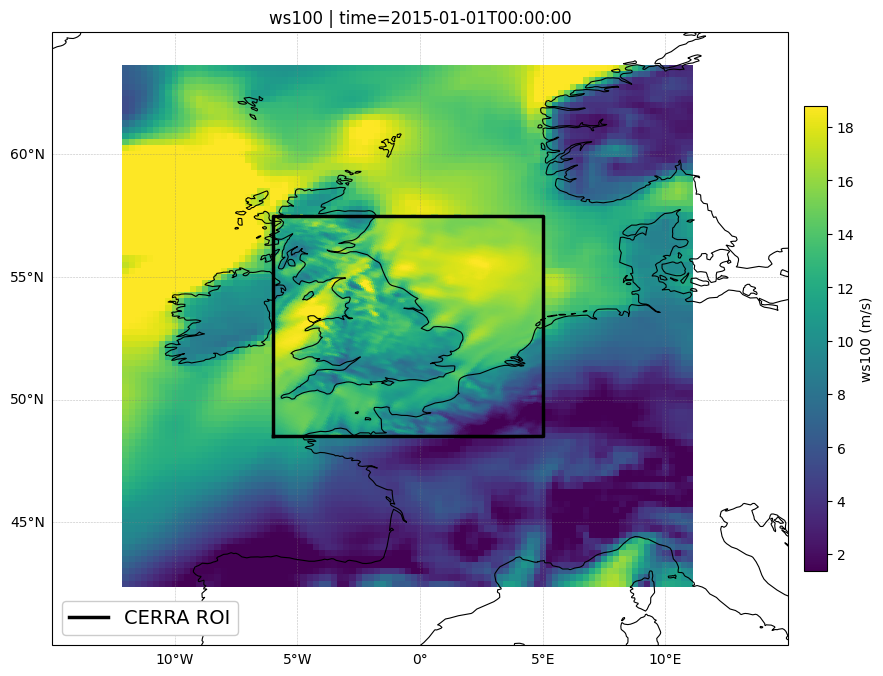

In [19]:
vmin = np.nanpercentile(np.concatenate([field_era5, field_cerra]), 2)
vmax = np.nanpercentile(np.concatenate([field_era5, field_cerra]), 98)

proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": proj})
ax.set_extent([-15, 15, 40, 65], crs=proj)

ax.scatter(lons_era5[outside], lats_era5[outside], c=field_era5[outside],
           cmap="viridis", vmin=vmin, vmax=vmax,
           s=20, marker="s", linewidths=0,
           transform=proj, rasterized=True, zorder=2)

sc = ax.scatter(lons_cerra, lats_cerra, c=field_cerra,
                cmap="viridis", vmin=vmin, vmax=vmax,
                s=4, marker="s", linewidths=0,
                transform=proj, rasterized=True, zorder=3)

ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.8, edgecolor="black", zorder=4)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="grey", alpha=0.5, linestyle="--", zorder=3)
gl.top_labels = False
gl.right_labels = False

ax.plot(box_lons, box_lats, color="black", linewidth=2.5, transform=proj, zorder=5)
ax.legend(handles=[mlines.Line2D([], [], color="black", lw=2.5, label="CERRA ROI")],
          loc="lower left", framealpha=1.0, fontsize=14)

fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, label=f"{variable_name} (m/s)", 
             shrink=1.0,      # height relative to axes (1.0 = full height)
             aspect=20)
ax.set_title(f"{variable_name} | time={timestamp}")
plt.show()

In [20]:
ds_out = xr.Dataset({
    "field_era5": xr.DataArray(field_era5, dims=["cell_era5"]),
    "field_cerra": xr.DataArray(field_cerra, dims=["cell_cerra"]),
    "lons_era5": xr.DataArray(lons_era5, dims=["cell_era5"]),
    "lats_era5": xr.DataArray(lats_era5, dims=["cell_era5"]),
    "lons_cerra": xr.DataArray(lons_cerra, dims=["cell_cerra"]),
    "lats_cerra": xr.DataArray(lats_cerra, dims=["cell_cerra"]),
}, attrs={"variable": variable_name, "time": timestamp})

ds_out.to_netcdf("ws100_plot_data.nc")

In [26]:
import torch 
graph = torch.load("/mnt/weatherloss/WindPower/graphs/EGU26/EGUgraph15km.pt", 
                   weights_only=False, 
                   map_location=torch.device('cpu'))
print(graph)

for node_type in graph.node_types:
    coords = graph[node_type].x
    print(f"{node_type}: NaN coords = {torch.isnan(coords).sum().item()} / {coords.numel()}")

HeteroData(
  data={
    x=[27821, 2],
    node_type='AnemoiDatasetNodes',
    area_weight=[27821, 1],
    cutout=[27821, 1],
    boundary=[27821, 1],
    indices_connected_nodes=[27821, 1],
  },
  hidden={
    x=[10682, 2],
    node_type='LimitedAreaTriNodes',
  },
  (data, to, hidden)={
    edge_index=[2, 126060],
    edge_type='KNNEdges,CutOffEdges',
    edge_length=[126060, 1],
    edge_dirs=[126060, 2],
  },
  (hidden, to, hidden)={
    edge_index=[2, 83802],
    edge_type='MultiScaleEdges',
    edge_length=[83802, 1],
    edge_dirs=[83802, 2],
  },
  (hidden, to, data)={
    edge_index=[2, 73332],
    edge_type='KNNEdges',
    edge_length=[73332, 1],
    edge_dirs=[73332, 2],
  }
)
data: NaN coords = 0 / 55642
hidden: NaN coords = 0 / 21364
